# Częściowy kolaps routingu — wczesne ostrzeganie presją gradientową

Orkiestrator kieruje zadania do dwudziestu workerów. Po przesunięciu rozkładu
ruchu część specjalistów przestaje dostawać zadania i ich routing zanika —
podczas gdy zagregowany rozkład dalej wygląda zdrowo.

**Pytanie:** czy presja gradientowa `min_k g_k` ostrzega wcześniej niż sam
rozkład routingu?

Hipotezy zapisano przed uruchomieniem: `PREREGISTRATION.md`. Metoda: `METODY.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from detectors import ema, sweep, table_at_far, first_persistent
from toy_partial_collapse import failure_time, T_SHIFT, CONDITIONS, RARE

# paleta zwalidowana pod widzenie barwne (CVD ΔE 9.2, normal ΔE 27.6)
BLUE, AQUA, ORANGE = "#2a78d6", "#1baf7a", "#eb6834"
INK, INK2 = "#0b0b0b", "#52514e"
SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5,
    "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
})

SEEDS = [0, 1, 2, 3, 4, 42]
runs = []
for c in CONDITIONS:
    for s in SEEDS:
        z = np.load(f"data/partial_{c}_seed{s}.npz")
        t, alive = failure_time(z)
        runs.append({"condition": c, "seed": s, "d": dict(z), "t_fail": t,
                     "label": "awaria" if t is not None else "null"})

for c in CONDITIONS:
    sub = [r for r in runs if r["condition"] == c]
    ts = [r["t_fail"] for r in sub if r["t_fail"]]
    print(f"{c:12s} awaria {len(ts)}/{len(sub)}   "
          f"mediana t_fail {int(np.median(ts)) if ts else '-'}")

shift        awaria 6/6   mediana t_fail 1095
stable       awaria 0/6   mediana t_fail -
mild_shift   awaria 1/6   mediana t_fail 1750
entropy_reg  awaria 6/6   mediana t_fail 1300


## Jak wygląda częściowy kolaps

Pokrycie każdego z 19 specjalistów w czasie: `c_k = P(routing do k | zadanie
z niszy k)`, mierzone na stałym zbiorze held-out. Sześć górnych wierszy to
nisze, które po przesunięciu stają się rzadkie.

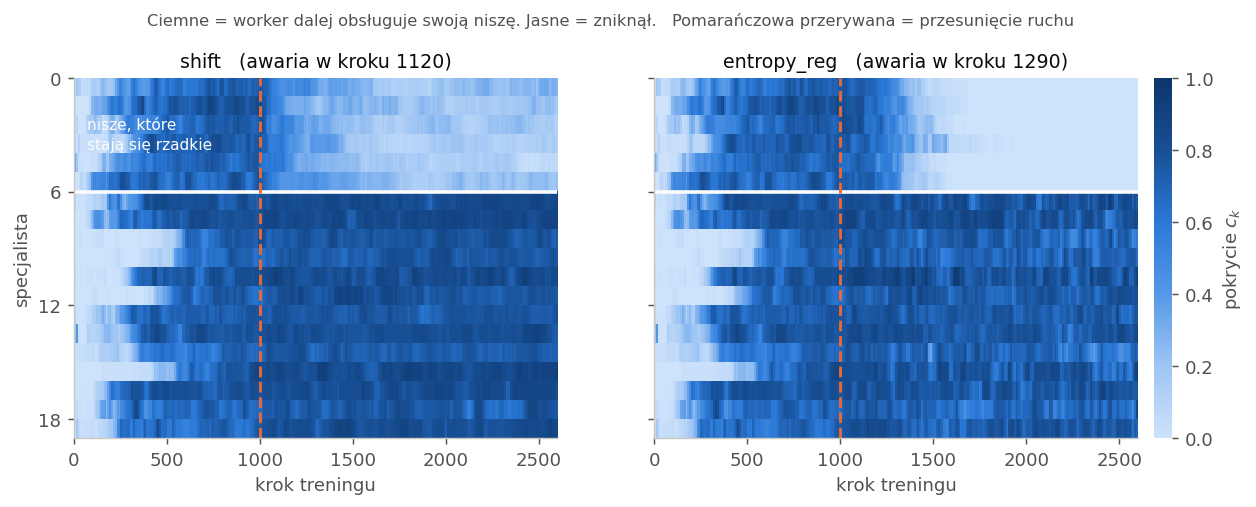

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
rare_idx = [k - 1 for k in RARE]
order = rare_idx + [k for k in range(19) if k not in rare_idx]

for ax, cond in zip(axes, ["shift", "entropy_reg"]):
    r = next(r for r in runs if r["condition"] == cond and r["seed"] == 0)
    cov, ev = r["d"]["coverage"][:, order].T, r["d"]["eval_step"]
    im = ax.imshow(cov, aspect="auto", cmap=SEQ, vmin=0, vmax=1,
                   extent=[ev[0], ev[-1], 19, 0], interpolation="nearest")
    ax.axhline(len(RARE), color="#fcfcfb", lw=2)
    ax.axvline(T_SHIFT, color=ORANGE, lw=1.6, ls="--")
    ax.set_title(f"{cond}   (awaria w kroku {r['t_fail']})")
    ax.set_xlabel("krok treningu")
axes[0].set_ylabel("specjalista")
for ax in axes:
    ax.set_yticks([0, 6, 12, 18])
axes[0].text(70, 3.0, "nisze, które\nstają się rzadkie", color="#fcfcfb",
             fontsize=8.5, va="center", linespacing=1.4)

cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.015)
cb.set_label("pokrycie $c_k$", color=INK2)
cb.outline.set_visible(False)
fig.suptitle("Ciemne = worker dalej obsługuje swoją niszę. Jasne = zniknął."
             "   Pomarańczowa przerywana = przesunięcie ruchu",
             fontsize=9, color=INK2, y=1.02)
plt.show()

Sześć rzadkich nisz gaśnie, trzynaście pozostałych działa dalej. To jest
kolaps *częściowy* — i właśnie dlatego agregat go nie widzi.

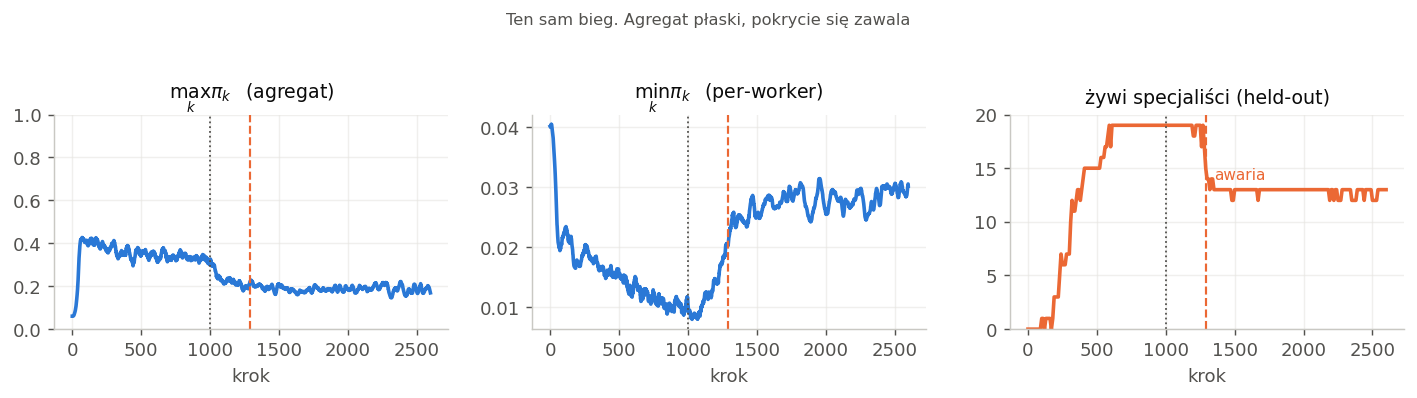

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))
r = next(r for r in runs if r["condition"] == "entropy_reg" and r["seed"] == 0)
d, ev = r["d"], r["d"]["eval_step"]
live = (d["coverage"] >= 0.5).sum(axis=1)

panels = [(np.arange(len(d["pi_mean"])), ema(d["pi_mean"].max(1)),
           "$\\max_k \\pi_k$  (agregat)", BLUE, (0, 1)),
          (np.arange(len(d["pi_mean"])), ema(d["pi_mean"].min(1)),
           "$\\min_k \\pi_k$  (per-worker)", BLUE, None),
          (ev, live, "żywi specjaliści (held-out)", ORANGE, (0, 20))]

for ax, (x, y, title, col, ylim) in zip(axes, panels):
    ax.plot(x, y, color=col, lw=2)
    ax.axvline(T_SHIFT, color=INK2, lw=1, ls=":")
    ax.axvline(r["t_fail"], color=ORANGE, lw=1.2, ls="--")
    ax.set_title(title); ax.set_xlabel("krok"); ax.grid(alpha=.6)
    if ylim: ax.set_ylim(*ylim)
axes[2].text(r["t_fail"] + 60, 14, "awaria", color=ORANGE, fontsize=8.5)
fig.suptitle("Ten sam bieg. Agregat płaski, pokrycie się zawala",
             fontsize=9, color=INK2, y=1.04)
plt.tight_layout(); plt.show()

## Sygnał presji jest transientem

Dla umierającego workera `g_k` schodzi na minus, osiąga dołek i **wraca do
zera** — gdy `pi_k → 0`, worker nie jest już próbkowany, więc
`g_k = −pi_k·E[A] → 0`. Alarm trzeba stawiać na dołku, nie na poziomie.

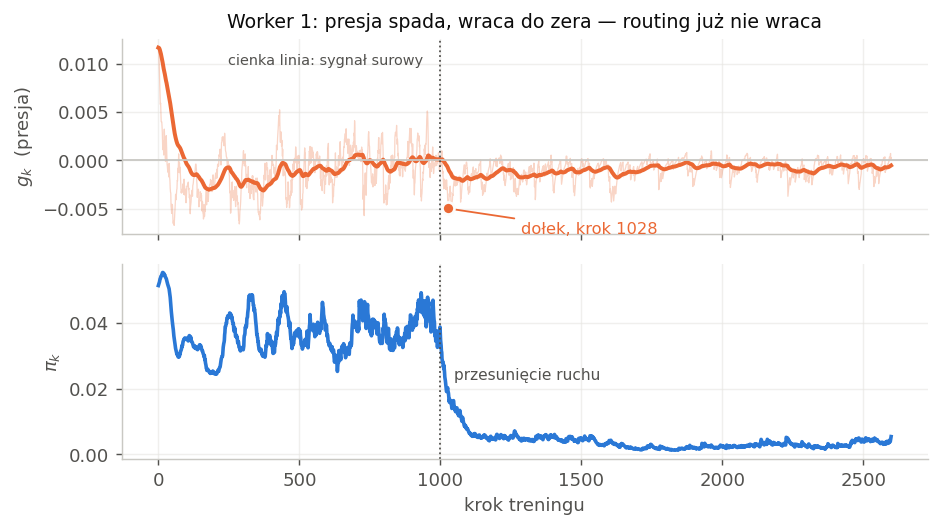

g_k:  przed +0.00040   dołek -0.00497   koniec +0.00028
pi_k: przed 0.0367   koniec 0.00546


In [4]:
z = np.load("data/partial_shift_seed0.npz")
k = int(RARE[0])
gk_raw = ema(z["g"][:, k])            # wygładzanie jak w statystyce alarmowej
gk = ema(gk_raw, alpha=0.02)          # dodatkowe, tylko do czytelności wykresu
pk = ema(z["pi_mean"][:, k])
tr = int(np.argmin(gk_raw[T_SHIFT:])) + T_SHIFT

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True,
                             gridspec_kw={"hspace": 0.15})
a1.plot(gk_raw, color=ORANGE, lw=0.7, alpha=0.28)
a1.plot(gk, color=ORANGE, lw=2.2)
a1.axhline(0, color="#c9c8c3", lw=1)
a1.scatter([tr], [gk_raw[tr]], s=44, color=ORANGE, zorder=5,
           edgecolor="#fcfcfb", linewidth=1.5)
a1.annotate(f"dołek, krok {tr}", (tr, gk_raw[tr]), (tr + 260, gk_raw[tr] - 0.0022),
            color=ORANGE, fontsize=9, va="center",
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1))
a1.set_ylabel("$g_k$  (presja)")
a1.set_title(f"Worker {k}: presja spada, wraca do zera — routing już nie wraca")

a2.plot(pk, color=BLUE, lw=2)
a2.set_ylabel("$\\pi_k$"); a2.set_xlabel("krok treningu")
for ax in (a1, a2):
    ax.axvline(T_SHIFT, color=INK2, lw=1, ls=":")
    ax.grid(alpha=.6)
a2.text(T_SHIFT + 50, pk[T_SHIFT] * 0.62, "przesunięcie ruchu",
        color=INK2, fontsize=8.5)
a1.text(T_SHIFT - 60, gk_raw.max() * 0.85, "cienka linia: sygnał surowy",
        color=INK2, fontsize=8, ha="right")
plt.show()

print(f"g_k:  przed {gk_raw[T_SHIFT-50:T_SHIFT].mean():+.5f}"
      f"   dołek {gk_raw[tr]:+.5f}   koniec {gk_raw[-1]:+.5f}")
print(f"pi_k: przed {pk[T_SHIFT]:.4f}   koniec {pk[-1]:.5f}")

## Porównanie monitorów przy dopasowanym FAR

Monitor alarmujący bez przerwy wygrywa na wyprzedzeniu i jest bezwartościowy,
więc lead ma sens wyłącznie przy ustalonym false-alarm rate. Biegi null to te,
w których awaria nie nastąpiła — niezależnie od warunku, z którego pochodzą.

In [5]:
def pmin(d):
    return ema(d["pi_mean"].min(1))

def bdiff(x):
    return np.diff(x, prepend=x[0])      # różnica wsteczna: wyłącznie przeszłość

MON = {
    "pi_max   (agregat)":      lambda d: ema(d["pi_mean"].max(1)),
    "pi_min   (poziom)":       lambda d: -pmin(d),
    "pi_slope (tempo)":        lambda d: -ema(bdiff(pmin(d)), alpha=0.05),
    "neg_entropy":             lambda d: -ema(d["entropy"]),
    "g_min    (presja)":       lambda d: -ema(d["g"].min(1)),
    "grad_norm":               lambda d: ema(d["grad_norm"]),
}
pos = [r for r in runs if r["label"] == "awaria"]
nul = [r for r in runs if r["label"] == "null"]
print(f"{len(pos)} biegów z awarią, {len(nul)} null\n")

curves = {n: sweep([(f(r["d"]), r["t_fail"]) for r in pos],
                   [f(r["d"]) for r in nul], start=T_SHIFT)
          for n, f in MON.items()}

for budget in (0.0, 0.10, 0.20):
    print(f"--- fałszywe alarmy <= {budget:.0%} ---")
    for n in MON:
        t = table_at_far(curves[n], budget)
        print(f"  {n:24s} wykryte {t['dr']:5.0%}  lead {t['mean_lead']:5.0f}"
              if t["feasible"] else f"  {n:24s} niewykonalne")
    print()

13 biegów z awarią, 11 null



--- fałszywe alarmy <= 0% ---
  pi_max   (agregat)       niewykonalne
  pi_min   (poziom)        wykryte   31%  lead    30
  pi_slope (tempo)         wykryte   62%  lead   133
  neg_entropy              niewykonalne
  g_min    (presja)        wykryte   46%  lead   177
  grad_norm                wykryte    8%  lead   243

--- fałszywe alarmy <= 10% ---
  pi_max   (agregat)       niewykonalne
  pi_min   (poziom)        wykryte   31%  lead    35
  pi_slope (tempo)         wykryte   69%  lead   153
  neg_entropy              niewykonalne
  g_min    (presja)        wykryte   54%  lead   178
  grad_norm                wykryte    8%  lead   245

--- fałszywe alarmy <= 20% ---
  pi_max   (agregat)       wykryte    8%  lead   462
  pi_min   (poziom)        wykryte   46%  lead    34
  pi_slope (tempo)         wykryte   77%  lead   169
  neg_entropy              niewykonalne
  g_min    (presja)        wykryte   69%  lead   235
  grad_norm                wykryte    8%  lead   257



## Poziom, tempo i presja na tych samych biegach

Trzy statystyki alarmowe, progi skalibrowane przy FAR ≤ 10%, ten sam seed
w obu kolumnach. Kropka = moment alarmu.

Monitor **tempa** nie był prerejestrowany — dodano go po obejrzeniu tych
wykresów, gdy okazało się, że kształt krzywej `min_k pi_k` przy przesunięciu
jest wzrokowo oczywisty, choć żaden próg na poziomie go nie łapie. Jest to
analiza po fakcie i tak jest oznaczona w `PREREGISTRATION.md`.

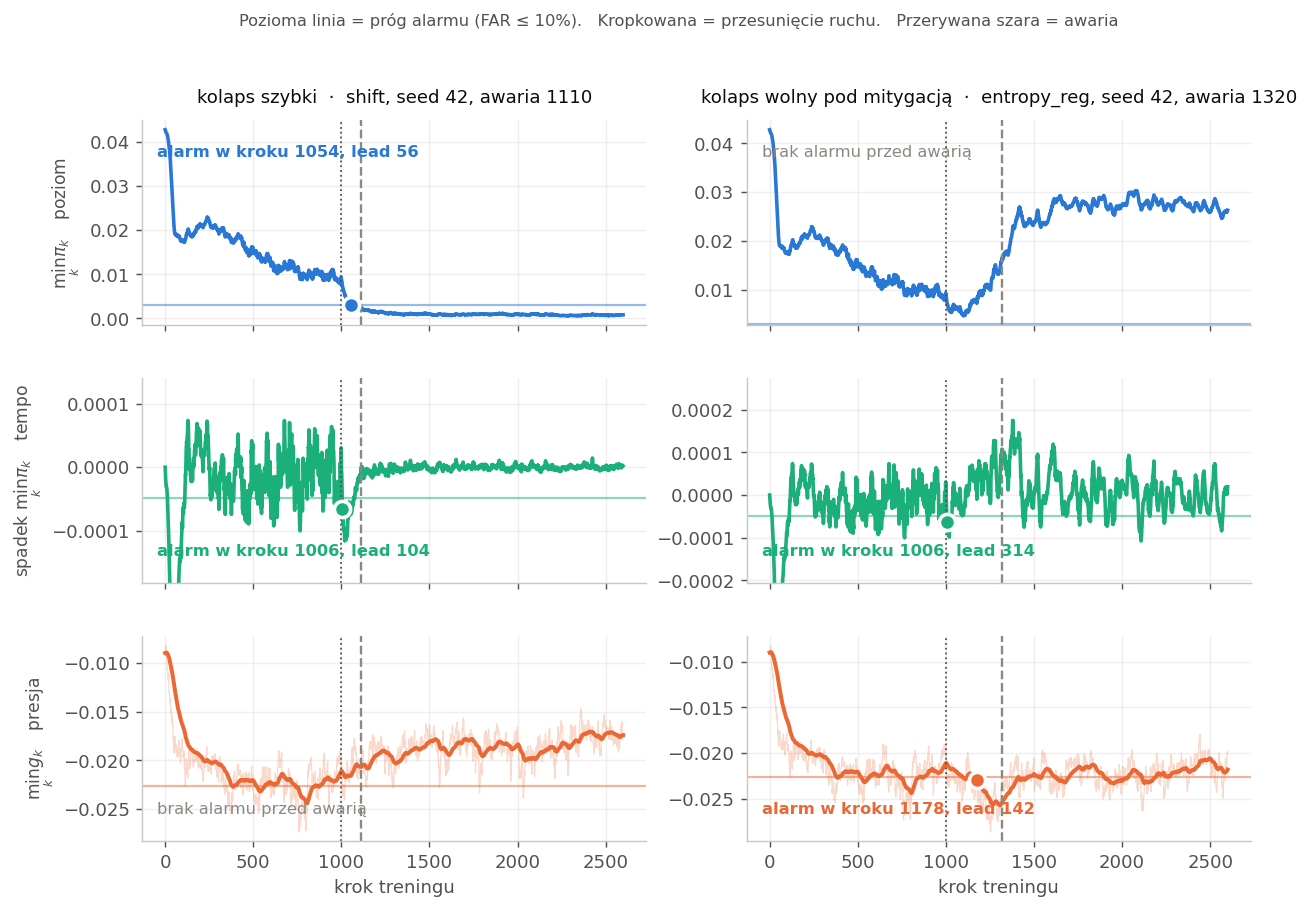

In [6]:
names = ["pi_min   (poziom)", "pi_slope (tempo)", "g_min    (presja)"]
labs = ["$\min_k \pi_k$   poziom", "spadek $\min_k \pi_k$   tempo",
        "$\min_k g_k$   presja"]
cols = [BLUE, AQUA, ORANGE]
thr = {n: table_at_far(curves[n], 0.10)["thr"] for n in names}
SEED = 42                      # ten sam seed w obu kolumnach

fig, axes = plt.subplots(3, 2, figsize=(11, 7.2), sharex=True,
                         gridspec_kw={"hspace": 0.26, "wspace": 0.2})
for j, cond in enumerate(["shift", "entropy_reg"]):
    r = next(r for r in runs if r["condition"] == cond and r["seed"] == SEED)
    for i, (n, col, lab) in enumerate(zip(names, cols, labs)):
        ax = axes[i, j]
        y = -MON[n](r["d"])                   # z powrotem do naturalnego znaku
        if i == 2:                            # presja: dodatkowe wygładzenie do czytelności
            ax.plot(y, color=col, lw=0.7, alpha=0.25)
            ax.plot(-ema(MON[n](r["d"]), alpha=0.02), color=col, lw=2.2)
        else:
            ax.plot(y, color=col, lw=2)
        if i == 1:            # tempo: przytnij transient rozruchowy
            w = y[300:]
            pad = (w.max() - w.min()) * 0.35
            ax.set_ylim(min(w.min(), -thr[n]) - pad, w.max() + pad)
        ax.axhline(-thr[n], color=col, lw=1.2, ls="-", alpha=.5)
        ax.axvline(T_SHIFT, color=INK2, lw=1, ls=":")
        ax.axvline(r["t_fail"], color="#8a8880", lw=1.3, ls="--")

        ta = first_persistent(MON[n](r["d"]) > thr[n], start=T_SHIFT)
        hit = ta is not None and ta < r["t_fail"]
        if hit:
            ax.scatter([ta], [y[ta]], s=80, color=col, zorder=6,
                       edgecolor="#fcfcfb", linewidth=2)
        ax.text(0.03, 0.12 if i in (1, 2) else 0.88,
                f"alarm w kroku {ta}, lead {r['t_fail']-ta}" if hit
                else "brak alarmu przed awarią",
                transform=ax.transAxes, fontsize=9,
                color=col if hit else "#8a8880",
                va="bottom" if i in (1, 2) else "top",
                fontweight="bold" if hit else "normal")
        ax.grid(alpha=.6); ax.set_axisbelow(True)
        if j == 0: ax.set_ylabel(lab, fontsize=9.5)
        if i == 0:
            head = "kolaps szybki" if cond == "shift" else "kolaps wolny pod mitygacją"
            ax.set_title(f"{head}  ·  {cond}, seed {SEED}, awaria {r['t_fail']}",
                         fontsize=10, pad=10)
        if i == 2: ax.set_xlabel("krok treningu")
fig.suptitle("Pozioma linia = próg alarmu (FAR ≤ 10%).   Kropkowana = przesunięcie ruchu.   "
             "Przerywana szara = awaria", fontsize=9, color=INK2, y=0.995)
plt.show()

**Górny wiersz — poziom.** Przy kolapsie szybkim spada pod próg i alarmuje.
Pod mitygacją **rośnie** z 0,005 do 0,027: monitor widzi poprawę dokładnie
wtedy, gdy sześciu specjalistów umiera.

**Środkowy wiersz — tempo.** Ten sam sygnał, tylko pochodna. Alarmuje w obu
kolumnach, bo przesunięcie ruchu daje charakterystyczne załamanie niezależnie
od tego, gdzie poziom akurat jest. To jest ten kształt, który widać okiem.

**Dolny wiersz — presja.** Przy kolapsie szybkim nie zdąży; pod mitygacją
schodzi pod próg i tam zostaje.

Wniosek: poziom rozkładu jest złym monitorem, jego pochodna dobrym, a gradient
dokłada te biegi, których pochodna nie łapie.

## Kluczowy wynik: monitory są komplementarne

Zbiorcze liczby ukrywają to, co najważniejsze. Poniżej lead dla każdego biegu
z awarią, przy FAR ≤ 10%.

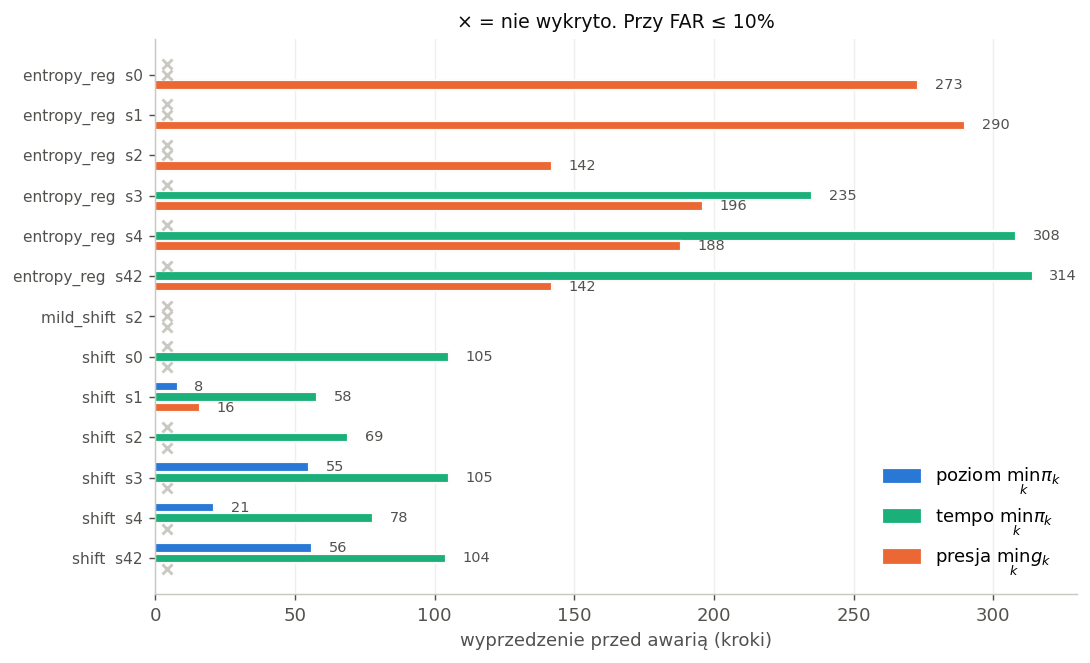

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ypos, ylabels = [], []
for i, r in enumerate(sorted(pos, key=lambda r: (r["condition"], r["seed"]))):
    ypos.append(i); ylabels.append(f"{r['condition']}  s{r['seed']}")
    for j, (n, col) in enumerate(zip(names, cols)):
        ta = first_persistent(MON[n](r["d"]) > thr[n], start=T_SHIFT)
        off = (j - 1) * 0.26
        if ta is not None and ta < r["t_fail"]:
            lead = r["t_fail"] - ta
            ax.barh(i + off, lead, height=0.24, color=col,
                    edgecolor="#fcfcfb", linewidth=1.2)
            ax.text(lead + 6, i + off, f"{lead}", va="center",
                    fontsize=8, color=INK2)
        else:
            ax.plot(4, i + off, marker="x", ms=5, color="#c9c8c3", mew=1.6)

ax.set_xlim(0, 330)
ax.set_yticks(ypos); ax.set_yticklabels(ylabels, fontsize=8.5)
ax.invert_yaxis(); ax.set_xlabel("wyprzedzenie przed awarią (kroki)")
ax.grid(axis="x", alpha=.6); ax.set_axisbelow(True)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cols]
ax.legend(handles, ["poziom $\\min_k \\pi_k$", "tempo $\\min_k \\pi_k$", "presja $\\min_k g_k$"],
          frameon=False, loc="lower right")
ax.set_title("× = nie wykryto. Przy FAR ≤ 10%")
plt.tight_layout(); plt.show()

## Test odporności: co, jeśli onset nie jest znany

Wszystko powyżej liczy alarmy dopiero od kroku przesunięcia. To daje każdemu
monitorowi darmową informację, której na prawdziwym systemie nie ma — i widać ją
na wykresie: przed krokiem 1000 presja spędza ok. 25% czasu pod progiem. Gdyby
liczyć alarmy od zera, **oba monitory alarmowałyby na 11/11 biegów null**.

Uczciwszy wariant: alarmy i fałszywe alarmy liczone od kroku 600, czyli po
rozruchu, ale 400 kroków **przed** przesunięciem. Monitor musi przemilczeć ten
odcinek stabilnej pracy.

In [8]:
def far_at(start):
    out = {}
    for n in ["pi_min   (poziom)", "pi_slope (tempo)", "g_min    (presja)"]:
        cur = sweep([(MON[n](r["d"]), r["t_fail"]) for r in pos],
                    [MON[n](r["d"]) for r in nul], start=start)
        out[n] = table_at_far(cur, 0.10)
    return out

for start, lab in ((T_SHIFT, "onset ZNANY   (start = krok przesunięcia)"),
                   (600,     "onset NIEznany (start = 600, po rozruchu)")):
    print(f"--- {lab} ---")
    for n, r in far_at(start).items():
        print(f"  {n:20s} DR={r['dr']:5.0%}  lead={r['mean_lead']:6.0f}"
              if r["feasible"] else f"  {n:20s} niewykonalne")
    print()

--- onset ZNANY   (start = krok przesunięcia) ---


  pi_min   (poziom)    DR=  31%  lead=    35
  pi_slope (tempo)     DR=  69%  lead=   153
  g_min    (presja)    DR=  54%  lead=   178

--- onset NIEznany (start = 600, po rozruchu) ---


  pi_min   (poziom)    DR=  31%  lead=    34
  pi_slope (tempo)     DR=  69%  lead=   153
  g_min    (presja)    DR=  38%  lead=   163



Tempo jest odporne — 69% w obu wariantach. **Presja traci jedną trzecią
detekcji** (54% → 38%), bo część jej alarmów wypadała blisko przesunięcia
i bez darmowego okna wpada w budżet fałszywych alarmów.

Para tempo + presja: 92% przy FAR 18% z onsetem, **85% przy FAR 9% bez niego**.
Presja dalej łapie 5/6 kolapsów pod mitygacją. Główny wniosek się broni, ale
pojedyncze liczby dla presji z tabel powyżej są zawyżone.

## Druga próba: pula null zawierająca tylko biegi z przesunięciem

Pula null powyżej to 6 biegów `stable` i 5 `mild_shift`. W `stable` w kroku
przesunięcia **nie dzieje się nic** — rozkład ruchu jest ten sam przed i po.
Ponad połowa puli null nie stawia więc żadnego pytania, a każdy monitor dostaje
tam darmowe zero.

Twardsza wersja: null = wyłącznie `mild_shift`, czyli biegi, w których
przesunięcie naprawdę nastąpiło i nikogo nie zabiło. Pytanie brzmi wtedy nie
„czy coś się zmieniło", tylko **„czy ta zmiana kogoś zabije"**.

In [9]:
hard = [r for r in nul if r["condition"] == "mild_shift"]
for pool, lab in ((nul, f"wszystkie null (n={len(nul)})"),
                  (hard, f"tylko mild_shift (n={len(hard)})")):
    print(f"--- null = {lab} ---")
    for n in ["pi_min   (poziom)", "pi_slope (tempo)", "g_min    (presja)"]:
        cur = sweep([(MON[n](r["d"]), r["t_fail"]) for r in pos],
                    [MON[n](r["d"]) for r in pool], start=T_SHIFT)
        r = table_at_far(cur, 0.20)      # przy n=5 najmniejszy niezerowy FAR to 20%
        print(f"  {n:20s} DR={r['dr']:5.0%}  lead={r['mean_lead']:6.0f}  FAR={r['far']:.0%}"
              if r["feasible"] else f"  {n:20s} niewykonalne")
    print()

# kiedy pada alarm wzgledem przesuniecia
for n in ["pi_slope (tempo)", "g_min    (presja)"]:
    thr = table_at_far(sweep([(MON[n](r["d"]), r["t_fail"]) for r in pos],
                             [MON[n](r["d"]) for r in nul], start=T_SHIFT), 0.10)["thr"]
    off = sorted(first_persistent(MON[n](r["d"]) > thr, start=T_SHIFT) - T_SHIFT
                 for r in pos
                 if (lambda ta: ta is not None and ta < r["t_fail"])(
                     first_persistent(MON[n](r["d"]) > thr, start=T_SHIFT)))
    print(f"{n}: alarmy padają {off} kroków po przesunięciu")

--- null = wszystkie null (n=11) ---
  pi_min   (poziom)    DR=  46%  lead=    34  FAR=18%


  pi_slope (tempo)     DR=  77%  lead=   169  FAR=18%
  g_min    (presja)    DR=  69%  lead=   235  FAR=18%

--- null = tylko mild_shift (n=5) ---
  pi_min   (poziom)    DR=  31%  lead=    35  FAR=20%


  pi_slope (tempo)     DR=  69%  lead=   153  FAR=20%
  g_min    (presja)    DR=  69%  lead=   237  FAR=20%



pi_slope (tempo): alarmy padają [2, 2, 2, 5, 5, 6, 6, 11, 15] kroków po przesunięciu
g_min    (presja): alarmy padają [17, 20, 44, 44, 68, 122, 178] kroków po przesunięciu


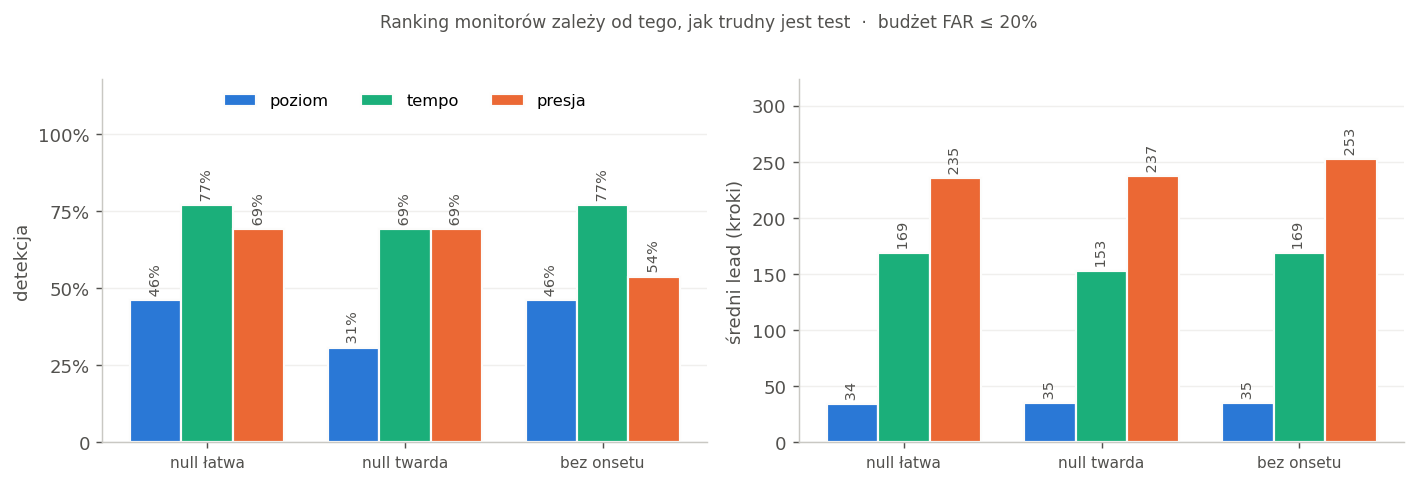

In [10]:
NAMES = ["pi_min   (poziom)", "pi_slope (tempo)", "g_min    (presja)"]
SHORT = ["poziom", "tempo", "presja"]
COLS  = [BLUE, AQUA, ORANGE]
hard  = [r for r in nul if r["condition"] == "mild_shift"]

# trzy warianty testu, ten sam budzet FAR <= 20% dla porownywalnosci
SCEN = [("null łatwa",     nul,  T_SHIFT),
        ("null twarda",    hard, T_SHIFT),
        ("bez onsetu",     nul,  600)]

res = {}
for lab, pool, st in SCEN:
    for n in NAMES:
        cur = sweep([(MON[n](r["d"]), r["t_fail"]) for r in pos],
                    [MON[n](r["d"]) for r in pool], start=st)
        res[(lab, n)] = table_at_far(cur, 0.20)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
x = np.arange(len(SCEN)); w = 0.26
for ax, key, ylab, fmt in ((axes[0], "dr", "detekcja", "{:.0%}"),
                           (axes[1], "mean_lead", "średni lead (kroki)", "{:.0f}")):
    for j, (n, sh, col) in enumerate(zip(NAMES, SHORT, COLS)):
        vals = [(res[(lab, n)][key] or 0) for lab, _, _ in SCEN]
        b = ax.bar(x + (j - 1) * w, vals, w, color=col, label=sh,
                   edgecolor="#fcfcfb", linewidth=1.2)
        for xi, v in zip(x + (j - 1) * w, vals):
            if v: ax.text(xi, v, " " + fmt.format(v), rotation=90, fontsize=8,
                          ha="center", va="bottom", color=INK2)
    ax.set_xticks(x); ax.set_xticklabels([l for l, _, _ in SCEN], fontsize=8.5)
    ax.set_ylabel(ylab); ax.grid(axis="y", alpha=.6); ax.set_axisbelow(True)
    if key == "dr":
        ax.set_ylim(0, 1.18)
        ax.set_yticks([0, .25, .5, .75, 1.0])
        ax.set_yticklabels(["0", "25%", "50%", "75%", "100%"])
    else:
        ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
axes[0].legend(frameon=False, ncol=3, fontsize=9, loc="upper center")
fig.suptitle("Ranking monitorów zależy od tego, jak trudny jest test  ·  budżet FAR ≤ 20%",
             fontsize=9.5, color=INK2, y=1.02)
plt.tight_layout(); plt.show()

Lewy panel: tempo wygrywa tylko na łatwej puli null. Gdy usunąć biegi
`stable`, w których w kroku przesunięcia nie dzieje się nic, remisuje z presją.
Gdy odebrać znajomość onsetu, presja traci najwięcej — bo część jej alarmów
wypadała blisko przesunięcia.

Prawy panel: **wyprzedzenie presji jest większe w każdym z trzech wariantów.**

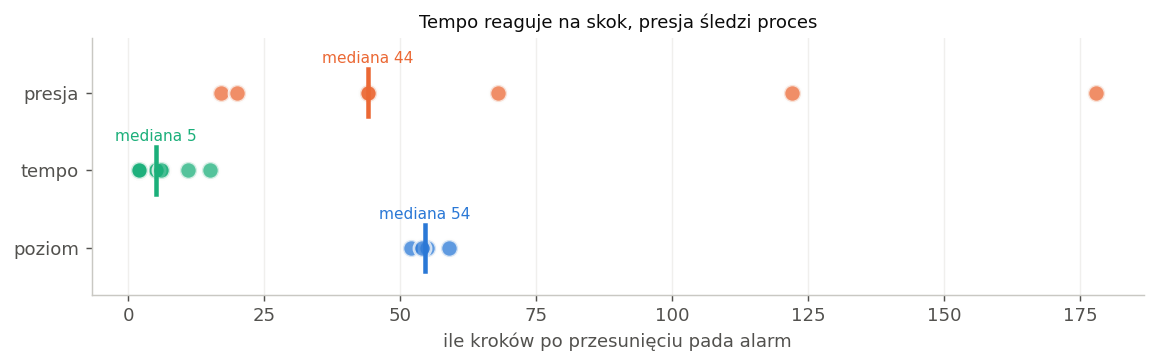

In [11]:
fig, ax = plt.subplots(figsize=(9, 2.9))
for i, (n, sh, col) in enumerate(zip(NAMES, SHORT, COLS)):
    thr = table_at_far(sweep([(MON[n](r["d"]), r["t_fail"]) for r in pos],
                             [MON[n](r["d"]) for r in nul], start=T_SHIFT), 0.10)["thr"]
    off = [first_persistent(MON[n](r["d"]) > thr, start=T_SHIFT) - T_SHIFT
           for r in pos
           if (lambda ta: ta is not None and ta < r["t_fail"])(
               first_persistent(MON[n](r["d"]) > thr, start=T_SHIFT))]
    if not off: continue
    ax.scatter(off, [i] * len(off), s=90, color=col, alpha=.75,
               edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
    ax.plot([np.median(off)] * 2, [i - .3, i + .3], color=col, lw=2.5, zorder=4)
    ax.text(np.median(off), i + .38, f"mediana {int(np.median(off))}",
            fontsize=8.5, color=col, ha="center")
ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(SHORT)
ax.set_xlabel("ile kroków po przesunięciu pada alarm")
ax.set_ylim(-.6, len(NAMES) - .3); ax.grid(axis="x", alpha=.6); ax.set_axisbelow(True)
ax.set_title("Tempo reaguje na skok, presja śledzi proces", fontsize=10)
plt.tight_layout(); plt.show()

Alarmy tempa skupiają się w pierwszych kilkunastu krokach po przesunięciu —
monitor reaguje na wielkość nieciągłości. Alarmy presji są rozrzucone przez
niemal 200 kroków, bo śledzi narastanie, a nie skok.

Stąd bierze się cała różnica w rankingu: na łatwej puli null wystarczy zauważyć
nieciągłość, na twardej trzeba odróżnić nieciągłość groźną od nieszkodliwej.

**Na twardej puli tempo i presja remisują na detekcji (69%), a presja daje
o połowę dłuższe wyprzedzenie: 237 kroków wobec 153.** Przewaga tempa z tabel
powyżej brała się z biegów `stable`, gdzie nie było czego wykrywać.

Czasy alarmów tłumaczą dlaczego. Tempo strzela 2–15 kroków po przesunięciu —
reaguje na wielkość samego skoku. Presja strzela 17–178 kroków po nim — śledzi
proces, który się rozwija. Na łatwej puli null wygrywa szybki refleks, na
twardej liczy się to, czy monitor odróżnia zmianę groźną od nieszkodliwej.

Zastrzeżenie: 5 biegów null, więc najmniejszy niezerowy FAR to 20% i
rozdzielczość jest zgrubna. Do rozstrzygnięcia potrzeba więcej seedów.

**Podział:**

| | poziom | tempo | presja |
|---|---|---|---|
| kolaps szybki | 4/6, lead 8–56 | **6/6, lead 58–105** | 1/6 |
| wolny pod mitygacją | 0/6 | 3/6, lead 235–314 | **6/6, lead 142–290** |

Największy pojedynczy zysk daje przejście z poziomu na tempo: 31% → 69%
detekcji, bez użycia gradientu.

Gradient dokłada to, czego polityka nie daje wcale — wszystkie sześć kolapsów
pod mitygacją. **Para tempo + presja: 92% detekcji przy 18% fałszywych
alarmów**, wobec 77% dla poziom + presja i 69% dla tempo + poziom.

## Ograniczenia

Detekcja jest niska bezwzględnie: najlepszy pojedynczy monitor łapie 54% awarii
przy FAR 10%. To dowód, że sygnał niesie informację niedostępną monitorom
rozkładu, a nie gotowy system.

Okno ewaluacji startuje w momencie przesunięcia, więc każdy monitor dostaje
onset za darmo. Na prawdziwym systemie onset nie jest znany i leady byłyby
krótsze. Instrukcja przeniesienia: `METODY.md`.